# Part 4 · From messy text to clean rows

**Building Agentic AI — Day 1, 12:25–13:00**

Playfield's studios don't want search results — they want answers:
*"What are the top complaints per game?"* That's a `groupby`. But the thing to
group by — sentiment, issue type — is **trapped inside prose**.

In this final part the LLM becomes a *data machine*: it reads each review and
fills in a **schema** we define. Text goes in, typed objects come out, `pandas`
does the rest.

In [1]:
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
from dotenv import load_dotenv
from google import genai
from google.genai import types

load_dotenv("../.env", override=True)
client = genai.Client()

MODEL = "gemini-3.5-flash-lite"

pd.set_option("display.max_colwidth", 100)

games = pd.read_csv("../data/games.csv")
df = pd.read_csv("../data/reviews.csv").merge(games, on="game_id")

CACHE = Path("cache")
CACHE.mkdir(exist_ok=True)

## 1. The question pandas can't answer (yet)

Here's a review. Quick — is it positive or negative?

In [2]:
trope = df[df["review_text"].str.contains("send help", case=False)]
print(trope["review_text"].iloc[0])
print("\nrecommended =", trope["recommended"].iloc[0])

400+ hours. NOT recommended. Do you understand? I have a family. I have a job. And yet every night I'm back in the Mossy Cellar telling myself one more run. The turnip familiar knows me better than my coworkers do. I can't stop playing. Send help.

recommended = False


A human reads this instantly. `str.contains("bad")` does not. Sentiment, sarcasm,
*which* problem the player is describing — none of it is a column. Our job:
**make it a column.**

## 2. Attempt 1: just ask for JSON

(Those of you who did exercise 7.3 this morning know where this is going.)

In [3]:
import json

review = df["review_text"].iloc[0]

r = client.models.generate_content(
    model=MODEL,
    contents=(
        "Reply ONLY with JSON like "
        '{"sentiment": "positive|negative|mixed", "issues": ["..."]} '
        f"for this game review:\n\n{review}"
    ),
)
print(r.text)

try:
    json.loads(r.text)
    print("\n✅ parsed")
except json.JSONDecodeError as e:
    print(f"\n💥 json.loads failed: {e}")

{"sentiment": "positive", "issues": ["combat is thin"]}

✅ parsed


Sometimes this works. Sometimes you get ` ```json ` fences, a friendly preamble,
or `"issues": "none really"` instead of a list. "Usually valid" is a demo;
pipelines need **always**.

## 3. Attempt 2: `response_schema` — a contract, not a request

We define the shape we want as a **Pydantic model**. The API then *constrains
generation itself* — the model literally cannot emit tokens that violate the
schema. No parsing, no praying:

In [4]:
from enum import Enum
from typing import Literal

from pydantic import BaseModel


class Issue(str, Enum):
    crashes_or_bugs = "crashes_or_bugs"
    performance = "performance"
    difficulty = "difficulty"
    monetization = "monetization"
    content_amount = "content_amount"
    multiplayer_or_netcode = "multiplayer_or_netcode"
    controls_or_ui = "controls_or_ui"
    other = "other"


class ReviewAnalysis(BaseModel):
    sentiment: Literal["positive", "negative", "mixed"]
    issues: list[Issue]
    is_sarcastic: bool
    summary: str  # one line, max ~15 words


def analyze(text: str) -> ReviewAnalysis:
    response = client.models.generate_content(
        model=MODEL,
        contents=f"Analyze this game review:\n\n{text}",
        config=types.GenerateContentConfig(
            response_mime_type="application/json",
            response_schema=ReviewAnalysis,
            temperature=0.0,
        ),
    )
    return response.parsed   # ← already a ReviewAnalysis object, not a string

In [5]:
result = analyze(trope["review_text"].iloc[0])

print(type(result))
print("sentiment:  ", result.sentiment)
print("issues:     ", [i.value for i in result.issues])
print("sarcastic:  ", result.is_sarcastic)
print("summary:    ", result.summary)

<class '__main__.ReviewAnalysis'>
sentiment:   negative
issues:      []
sarcastic:   True
summary:     The reviewer does not recommend the game despite playing for 400+ hours, humorously describing it as an irresistible addiction that is ruining their personal life.


A typed Python object came back from *prose*. This is the bridge between the
fuzzy world of language and the strict world of code — and it's how agents will
pass data between each other on Day 4.

## 4. Scale it: analyze 40 reviews

We'll process 10 reviews from each of 4 very different games. Two practical notes:

- **Cost & time**: 40 sequential calls take a few minutes on the free tier
  (rate limits). This is *exactly* why Day 5's system will be an agent — it
  doesn't get bored. Let it run; read the code while it does.
- **Caching again**: results land in `cache/analysis.csv`; re-running is free.

In [6]:
SAMPLE_GAMES = ["g01", "g05", "g09", "g16"]   # a racer, an MMO, a metroidvania, a rough launch

sample = (
    df[df["game_id"].isin(SAMPLE_GAMES)]
    .groupby("game_id")
    .head(10)
    .reset_index(drop=True)
)
print(f"{len(sample)} reviews from: {sorted(sample['title'].unique())}")

40 reviews from: ['Glacier Punk', 'Moth Light', 'Neon Drift Racers', 'Pixel Pirates Online']


In [7]:
ANALYSIS_FILE = CACHE / "analysis.csv"

if ANALYSIS_FILE.exists():
    analysis = pd.read_csv(ANALYSIS_FILE)
    print("loaded from cache ✅")
else:
    rows = []
    for i, r in sample.iterrows():
        for attempt in range(7):
            try:
                a = analyze(r["review_text"])
                break
            except genai.errors.APIError:
                time.sleep(2**attempt)
        else:
            raise RuntimeError(f"analysis failed for {r['review_id']}")
        rows.append(
            {
                "review_id": r["review_id"],
                "title": r["title"],
                "recommended": r["recommended"],
                "sentiment": a.sentiment,
                "issues": "|".join(i.value for i in a.issues),
                "is_sarcastic": a.is_sarcastic,
                "summary": a.summary,
            }
        )
        if (i + 1) % 10 == 0:
            print(f"  analyzed {i + 1}/{len(sample)}")
    analysis = pd.DataFrame(rows)
    analysis.to_csv(ANALYSIS_FILE, index=False)

analysis.head(5)

  analyzed 10/40
  analyzed 20/40
  analyzed 30/40
  analyzed 40/40


,review_id,title,recommended,sentiment,issues,is_sarcastic,summary
0,r004,Neon Drift Racers,True,positive,crashes_or_bugs,False,The reviewer changed their rating to positive after patch 1.4 successfully resolved the previous...
1,r005,Glacier Punk,True,mixed,crashes_or_bugs,False,"The game has immense ambition and unique beauty, but is currently hindered by technical issues."
2,r006,Glacier Punk,False,negative,crashes_or_bugs,False,"The reviewer experienced severe animation bugs with NPCs and a progression-blocking quest bug, a..."
3,r009,Neon Drift Racers,True,mixed,crashes_or_bugs,False,"The reviewer loves the arcade racer's handling, making it their favorite of the decade, but expe..."
4,r011,Glacier Punk,False,negative,crashes_or_bugs,False,The reviewer experienced a broken save file and advises waiting a year for the game to be fixed.


## 5. Now pandas CAN answer

Sentiment per game — extracted from prose, aggregated in one line:

In [8]:
pd.crosstab(analysis["title"], analysis["sentiment"], normalize="index").round(2)

sentiment,mixed,negative,positive
title,,,
Glacier Punk,0.3,0.4,0.3
Moth Light,0.1,0.0,0.9
Neon Drift Racers,0.3,0.2,0.5
Pixel Pirates Online,0.2,0.7,0.1


**The chart Playfield's studios asked for** — what should each team fix first?

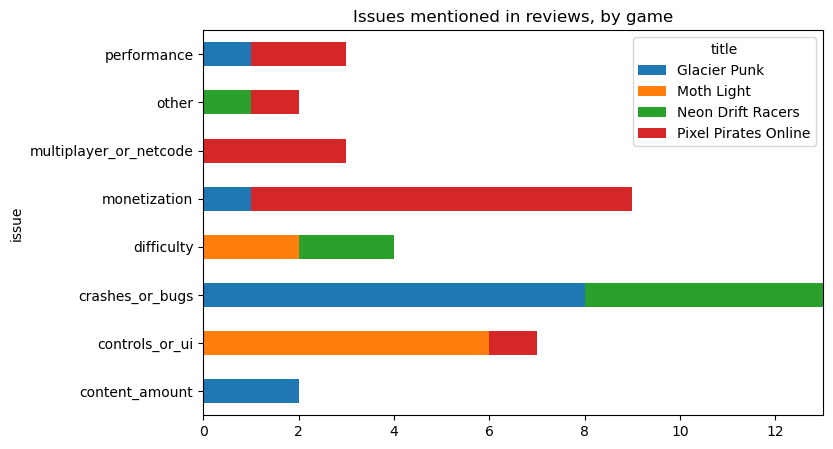

In [9]:
issue_counts = (
    analysis.assign(issue=analysis["issues"].str.split("|"))
    .explode("issue")                # one row per (review, issue) — duplicates the index!
    .query("issue != ''")
    .reset_index(drop=True)          # crosstab needs a unique index
)

pd.crosstab(issue_counts["issue"], issue_counts["title"]).plot(
    kind="barh", stacked=True, figsize=(8, 5),
    title="Issues mentioned in reviews, by game",
);

Compare against what you *already know* from building the dataset story:
the racer's crash cluster, the MMO's monetization anger, the rough launch —
all extracted automatically from raw text. 🎯

One more: where the **thumbs lie**. Recommended, but the text is negative:

In [10]:
analysis[(analysis["recommended"]) & (analysis["sentiment"] == "negative")][
    ["title", "sentiment", "is_sarcastic", "summary"]
]

,title,sentiment,is_sarcastic,summary


Those are your sarcastic "400 hours, do not recommend, send help" reviewers.
The label says one thing, the text says another — **structured extraction sees
what `value_counts` can't.** (And note: sarcasm is *still* hard; check whether
`is_sarcastic` got them all. Model output is a judgment, not ground truth —
that thought becomes Day 5's evaluation lesson.)

## 6. The reveal

Look at what you did today, *by hand*:

1. **Part 3**: searched 300 reviews by meaning → found what players say
2. **Part 4**: extracted structure from prose → counted it
3. **pandas**: aggregated → "here's what to fix first"

That pipeline — *retrieve → extract → analyze → report* — **is** the multi-agent
system you'll demo on the last day. The only thing missing is the part where *the model
decides which step to run*. That's next time:

```python
# Day 2 preview (don't run this yet — this is ADK, next time's toolkit)
from google.adk.agents import LlmAgent

analyst = LlmAgent(
    model="gemini-2.5-flash",
    name="playfield_analyst",
    instruction="You answer questions about Playfield's games using your tools.",
    tools=[search_reviews, analyze_review],   # ← today's functions, wrapped
)
```

## 7. Exercises

**7.1 — Severity (⭐)** Add `severity: Literal["minor", "major", "game_breaking"]`
to `ReviewAnalysis` and re-run on 10 reviews of one game. Do severities match your reading?

**7.2 — Feature requests (⭐⭐)** Add `feature_requests: list[str]` (what players
*ask for*, not what they complain about). Which of the 4 games' players want the most?

**7.3 — Cross-check the devs (⭐⭐)** Run the analysis on `g12` (Silent Depths),
then open `data/docs/g12-patch-notes.md`. Did the developers fix what players
complain about? Note the dates. (You are now doing Day 4's job by hand.)

**7.4 — Mini-pipeline (⭐⭐⭐)** Chain everything: `search("crashes and technical problems")`
→ `analyze()` each hit → print one verdict line per game found. Congratulations —
you've written Day 5's system as a script. Next session we make it *decide*.

In [11]:
# 7.1 — your code here

In [12]:
# 7.2 — your code here

In [13]:
# 7.3 — your code here

In [14]:
# 7.4 — your code here

---
## ✅ Day 1 complete

You went from "what's a token?" to a working retrieve→extract→analyze pipeline.
**Keep every function you wrote today** — `search()` and `analyze()` return as
agent tools on Days 2–3, and the whole pipeline returns as a multi-agent system
on Day 4.

📝 Before you leave: run the last cell of each notebook once more if it errored —
the Day-2 scaffold assumes today's cache files exist.